In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("customer_segmentation.csv")

print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
# check null values
print(data.isnull().sum())

# encode Gender
data['Gender'] = data['Gender'].map({'Male':0, 'Female':1})

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [ ]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

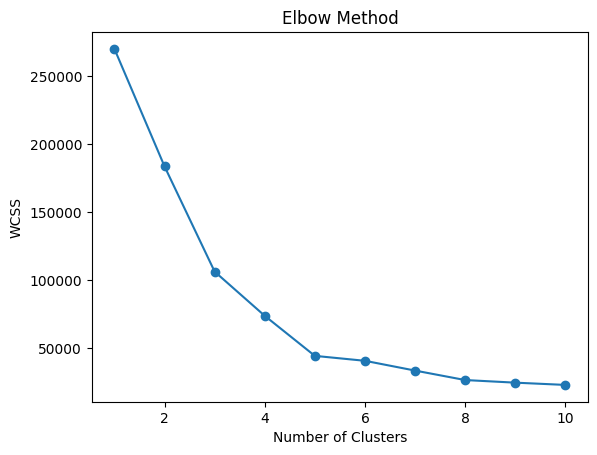

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# plot elbow graph
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# add cluster column
data['Cluster'] = y_kmeans

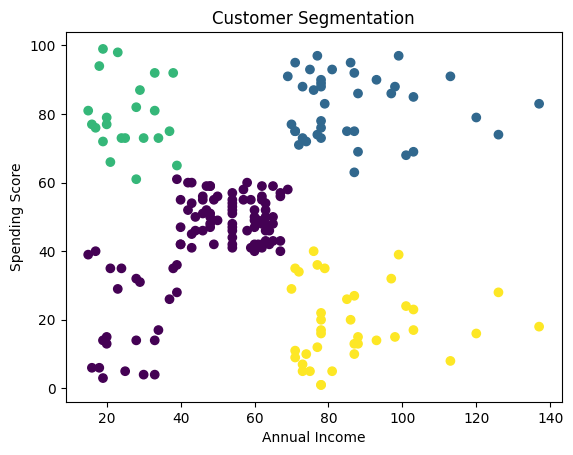

In [ ]:
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'],
            c=y_kmeans)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")
plt.show()

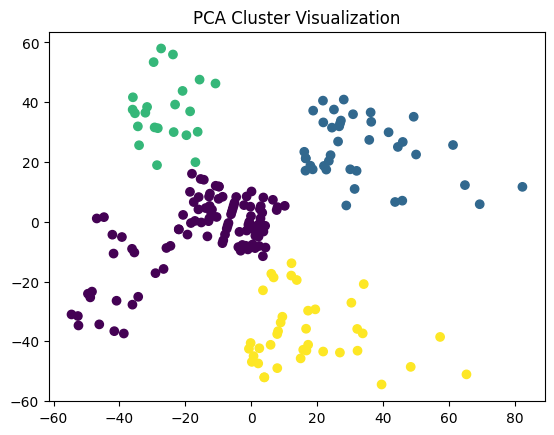

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_kmeans)
plt.title("PCA Cluster Visualization")
plt.show()

In [ ]:
print(data.groupby('Cluster').mean())

         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0         70.475248  0.594059  43.603960           48.168317   
1        162.000000  0.538462  32.692308           86.538462   
2         23.090909  0.590909  25.272727           25.727273   
3        162.000000  0.473684  40.394737           87.000000   

         Spending Score (1-100)  
Cluster                          
0                     43.396040  
1                     82.128205  
2                     79.363636  
3                     18.631579  


In [ ]:
for i in range(4):
    print("\nCluster", i)
    print(data[data['Cluster'] == i].head())


Cluster 0
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       0   19                  15                      39   
2           3       1   20                  16                       6   
4           5       1   31                  17                      40   
6           7       1   35                  18                       6   
8           9       0   64                  19                       3   

   Cluster  
0        0  
2        0  
4        0  
6        0  
8        0  

Cluster 1
     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
123         124       0   39                  69                      91   
125         126       1   31                  70                      77   
127         128       0   40                  71                      95   
129         130       0   38                  71                      75   
131         132       0   39                  71                      75   